In [1]:
import os
import sys
import uproot
import awkward as ak
import numpy as np
from coffea import nanoevents
import vector
from rich import print
import matplotlib.pyplot as plt
import matplotlib
import mplhep as hep
from hist import Hist
from tqdm import tqdm

In [2]:
sys.path.insert(0, "../../workflows/")

In [3]:
matplotlib.rcParams.update({"figure.max_open_warning": 0})
hep.style.use(hep.style.CMS)

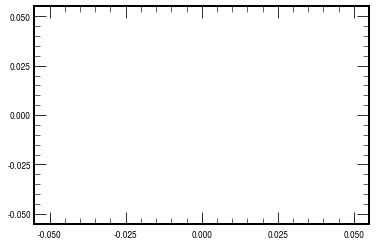

In [4]:
plt.plot()
hep.style.use(hep.style.CMS)

In [5]:
np.set_printoptions(precision=2)

In [6]:
vector.register_awkward()

In [ ]:
/QCD_HT1000to1500_TuneCP5_13TeV-madgraphMLM-pythia8/RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v1/NANOAODSIM
--> Looks ok!

/QCD_HT1000to1500_TuneCP5_PSWeights_13TeV-madgraph-pythia8/RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v1/NANOAODSIM
--> Looks ok!

In [ ]:
/QCD_HT1000to1500_TuneCP5_13TeV-madgraphMLM-pythia8/RunIISummer20UL17NanoAODv9-106X_mc2017_realistic_v9-v1/NANOAODSIM
--> Looks ok!

/QCD_HT1000to1500_TuneCP5_PSWeights_13TeV-madgraph-pythia8/RunIISummer20UL17NanoAODv9-106X_mc2017_realistic_v9-v1/NANOAODSIM
--> Looks ok!

In [ ]:
/QCD_HT1000to1500_TuneCP5_PSWeights_13TeV-madgraph-pythia8/RunIISummer20UL16NanoAODv9-106X_mcRun2_asymptotic_v17-v1/NANOAODSIM
--> Looks ok!

/QCD_HT1000to1500_TuneCP5_PSWeights_13TeV-madgraphMLM-pythia8/RunIISummer20UL16NanoAODv9-106X_mcRun2_asymptotic_v17-v1/NANOAODSIM
--> Looks ok!

In [ ]:
/QCD_HT1000to1500_TuneCP5_PSWeights_13TeV-madgraph-pythia8/RunIISummer20UL16NanoAODAPVv9-106X_mcRun2_asymptotic_preVFP_v11-v1/NANOAODSIM

/QCD_HT1000to1500_TuneCP5_PSWeights_13TeV-madgraphMLM-pythia8/RunIISummer20UL16NanoAODAPVv9-106X_mcRun2_asymptotic_preVFP_v11-v1/NANOAODSIM

In [39]:
file = nanoevents.NanoEventsFactory.from_root(
    "root://cmsxrootd.fnal.gov//store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt_1000to1400_TuneCP5_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/270000/1CC03E37-F7F9-1941-9C7E-BC3C3A1A6287.root",
    schemaclass=nanoevents.NanoAODSchema,
)

events = file.events()

In [40]:
events.PSWeight

<Array [[1], [1], [1], ... [1], [1], [1]] type='106000 * [var * float32[paramete...'>

In [41]:
events.LHEPdfWeight

AttributeError: no field named 'LHEPdfWeight'

(https://github.com/scikit-hep/awkward-1.0/blob/1.10.5/src/awkward/highlevel.py#L1124)

In [38]:
events.LHEScaleWeight

<Array [[1.26, 1.09, 0.951, ... 0.923, 0.836]] type='33536 * [var * float32[para...'>

In [7]:
xrd_path = "root://cmseos.fnal.gov//store/group/lpcsuep/"

qcd = "QCD_Pt-300To470_MuEnrichedPt5_TuneCP5_13TeV-pythia8"
wjets = "WJetsToLNu_HT-70To100_TuneCP5_13TeV-madgraphMLM-pythia8"
dyjets = "DYJetsToLL_M-50_TuneCP5_13TeV-amcatnloFXFX-pythia8"
tt = "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8"
higgs = "GluGluHToZZTo4L_M125_TuneCP5_13TeV_powheg2_minloHJJ_JHUGenV7011_pythia8"
suep = "GluGluToSUEP_T1p40_TuneCP5_13TeV_pythia8_split/SUEP_mS1000.000_mPhi1.400_T1.400_modehadronic"
zzto2l2nu = "ZZTo2L2Nu_TuneCP5_13TeV_powheg_pythia8"
zz = "ZZTo2L2Nu_TuneCP5_13TeV_powheg_pythia8"

file = nanoevents.NanoEventsFactory.from_root(
    f"{xrd_path}/Muon_counting_search/SUEPNano_UL16_Nov2024_merged/{qcd}/merged_0.root",
    schemaclass=nanoevents.NanoAODSchema,
)

events = file.events()

In [10]:
Q = events.Generator.scalePDF
id1 = events.Generator.id1
id2 = events.Generator.id2
x1 = events.Generator.x1
x2 = events.Generator.x2

In [11]:
import parton

In [17]:
pdfweights = []
for i in range(103):
    pdf = parton.mkPDF("NNPDF31_nnlo_as_0118_mc_hessian_pdfas", member=i)
    newpdf1 = pdf.xfxQ(id1, x1, Q, grid=False) / x1
    newpdf2 = pdf.xfxQ(id2, x2, Q, grid=False) / x2
    pdfweights.append(newpdf1 * newpdf2)
pdfweights = np.array(pdfweights).T
lhepdfweights = pdfweights[:, 1:] / pdfweights[:, 0][:, np.newaxis]

In [18]:
print(lhepdfweights)

[[1.   1.01 0.98 ... 1.   0.94 1.08]
 [1.   1.   1.   ... 1.   1.01 1.  ]
 [1.   1.   1.   ... 1.   1.   0.99]
 ...
 [1.   1.   1.   ... 1.   1.01 1.  ]
 [1.   1.   1.   ... 1.   1.01 1.  ]
 [1.   1.   1.   ... 1.   1.01 0.99]]

In [11]:
events.LHEPdfWeight[:100, 1].to_numpy()

AttributeError: no field named 'LHEPdfWeight'

(https://github.com/scikit-hep/awkward-1.0/blob/1.10.5/src/awkward/highlevel.py#L1124)

In [16]:
import parton


def manual_pdf_weights(events):
    """
    Get the matrix element PDF variations manually by evaluating all the PDF
    replicas for the given x, id, Q values for the two partons.
    """
    Q = events.Generator.scalePDF
    id1 = np.where(abs(events.Generator.id1) == 21, 0, events.Generator.id1)
    id2 = np.where(abs(events.Generator.id2) == 21, 0, events.Generator.id2)
    x1 = events.Generator.x1
    x2 = events.Generator.x2
    pdfweights = []
    for i in range(103):
        pdf = parton.mkPDF("NNPDF31_nnlo_as_0118_mc_hessian_pdfas", i)
        newpdf1 = pdf.xfxQ(id1, x1, Q, grid=False) / x1
        newpdf2 = pdf.xfxQ(id2, x2, Q, grid=False) / x2
        pdfweights.append(newpdf1 * newpdf2)
    pdfweights = np.array(pdfweights).T
    return pdfweights / pdfweights[:, 0][:, np.newaxis]


def get_pdf_weights(events, allow_manual=True):
    """
    Get the matrix element PDF weights. Only available if there is LHE info.
    If the LHEPdfWeight is not available, the weights are calculated manually.
    This behavior can be disabled by setting allow_manual to False.
    """
    if "LHEPdfWeight" in events.fields:
        if len(events.LHEPdfWeight[0]) > 0:
            pdf_weights = events.LHEPdfWeight
            if not all(ak.flatten(events.LHEPdfWeight) >= 0):
                if allow_manual:
                    pdf_weights = manual_pdf_weights(events)
                else:
                    pdf_alt = 1
                pdf_weights = np.where(
                    events.LHEPdfWeight.to_numpy() >= 0, pdf_weights, pdf_alt
                )
        elif allow_manual:
            pdf_weights = manual_pdf_weights(events)
        else:
            return np.ones((len(events), 103))
    elif allow_manual:
        pdf_weights = manual_pdf_weights(events)
    else:
        return np.ones((len(events), 103))
    return pdf_weights

In [17]:
get_pdf_weights(events)

array([[1.  , 1.  , 1.  , ..., 1.  , 0.99, 1.01],
       [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
       [1.  , 1.01, 1.  , ..., 1.  , 1.  , 0.99],
       ...,
       [1.  , 1.  , 1.  , ..., 1.  , 1.01, 1.  ],
       [1.  , 1.  , 1.  , ..., 1.  , 1.01, 1.  ],
       [1.  , 1.  , 1.  , ..., 1.  , 0.99, 1.01]])

In [43]:
events.LHEPdfWeight[events.LHEPdfWeight.to_numpy() < 0]

<Array [] type='0 * float32[parameters={"__doc__": "LHE pdf variation weights (w...'>

In [10]:
import parton

In [13]:
Q = events.Generator.scalePDF
id1 = events.Generator.id1
id2 = events.Generator.id2
x1 = events.Generator.x1
x2 = events.Generator.x2
# pdfweights = []
# for i in tqdm(range(103)):
#     pdf = parton.mkPDF("NNPDF31_nnlo_as_0118_mc_hessian_pdfas", i)
#     newpdf1 = pdf.xfxQ(events.Generator.id1, x1, Q**2, grid=False) / x1
#     newpdf2 = pdf.xfxQ(events.Generator.id2, x2, Q**2, grid=False) / x2
#     pdfweights.append(newpdf1 * newpdf2)
# pdfweights = np.array(pdfweights).T

In [24]:
!python3 -m parton install 'NNPDF31_nnlo_as_0118_mc_pdfas'

No PDF sets matching the pattern NNPDF31_nnlo_as_0118_mc_pdfas found.


In [25]:
i = 0
pdfset = "NNPDF31_nnlo_as_0118_mc_hessian_pdfas"
print("id1:", events.Generator.id1[i])
print("x1:", x1[i])
print("Q:", Q[i])
pdf = parton.mkPDF(pdfset, 0)
w0 = pdf.xfxQ(events.Generator.id1[i], x1[i], Q[i])
print("pdf0:", w0 / w0)
print("pdf0:", events.LHEPdfWeight[i, 0])
print()

pdf = parton.mkPDF(pdfset, 1)
print("pdf1:", pdf.xfxQ(events.Generator.id1[i], x1[i], Q[i]) / w0)
print("pdf1:", events.LHEPdfWeight[i, 1])
print()

pdf = parton.mkPDF(pdfset, 2)
print("pdf2:", pdf.xfxQ(events.Generator.id1[i], x1[i], Q[i]) / w0)
print("pdf2:", events.LHEPdfWeight[i, 2])
print()

pdf = parton.mkPDF(pdfset, 3)
print("pdf3:", pdf.xfxQ(events.Generator.id1[i], x1[i], Q[i]) / w0)
print("pdf3:", events.LHEPdfWeight[i, 3])
print()

pdf = parton.mkPDF(pdfset, 4)
print("pdf4:", pdf.xfxQ(events.Generator.id1[i], x1[i], Q[i]) / w0)
print("pdf4:", events.LHEPdfWeight[i, 4])
print()

id1: 21

x1: 0.04349327087402344

Q: 40.32421875

pdf0: 1.0

pdf0: 1.0

...

pdf2: 1.00079345703125

pdf3: 0.9987132381897106

pdf3: 1.00079345703125

pdf4: 1.0011400213161432

pdf4: 1.00225830078125

In [118]:
LHEPdfWeight = pdfweights / pdfweights[:, 0][:, np.newaxis]

In [125]:
list(LHEPdfWeight[:20, 102])

[0.9936726600233314,
 0.9966122619868277,
 0.9949249897188854,
 0.9969377807346659,
 1.0302563604720159,
 0.989907117614356,
 0.991645615379983,
 nan,
 0.9917153949521723,
 0.9972950079296086,
 0.9920465848662378,
 0.9936626077236325,
 0.9976264363812303,
 0.9905964989776084,
 0.9930838850937537,
 0.9936581453243778,
 0.9912618775365304,
 0.992218940505198,
 0.9944544823578518,
 0.9935131544278111]

In [126]:
events.LHEPdfWeight[:20, 102].to_list()

[1.02349853515625,
 1.02691650390625,
 1.02850341796875,
 1.02777099609375,
 1.0313720703125,
 1.02325439453125,
 1.02239990234375,
 1.03961181640625,
 1.02490234375,
 1.05560302734375,
 1.0396728515625,
 1.0240478515625,
 1.0234375,
 1.0291748046875,
 1.02142333984375,
 1.0264892578125,
 1.01434326171875,
 1.02606201171875,
 1.02447509765625,
 1.00433349609375]

In [107]:
import lhapdf

In [111]:
p = lhapdf.mkPDF("NNPDF31_nnlo_as_0118_mc_hessian_pdfas", 0)
pdf = parton.mkPDF("NNPDF31_nnlo_as_0118_mc_hessian_pdfas", 0)

LHAPDF 6.5.3 loading /cvmfs/sft.cern.ch/lcg/external/lhapdfsets/current/NNPDF31_nnlo_as_0118_mc_hessian_pdfas/NNPDF31_nnlo_as_0118_mc_hessian_pdfas_0000.dat
NNPDF31_nnlo_as_0118_mc_hessian_pdfas PDF set, member #0, version 1; LHAPDF ID = 325300


In [132]:
print(p.xfxQ(21, 1e-3, 1e4))
print(pdf.xfxQ(21, 1e-3, 1e4))

45.48289971957226

45.33174980088794

In [128]:
help(p.xfxQ)

Help on method xfxQ in module lhapdf.lhapdf:

xfxQ(*args) method of python.lhapdf.PDF instance
    PDF.xfxQ(self, *args)
    Return the PDF xf(x,Q2) value for the given parton ID, x, and Q values.
    
            Two forms of arguments are allowed:
            3-args: (pid, x, q)
              If all are scalars, a scalar is returned; if pid is a sequence, a list is
              returned; if x and q are sequences of the same length, they will be zipped
              and a (maybe nested) list of the return values as for scalar x/q will be returned.
              If pid is None, behave like the 2-arg version.
            2-args: (x, q)
              As for 3 args, but always returning results for all PIDs, as a dict. The return
              will be many such dicts in a zipped list if x/q are sequences.

